24 24 24
u (km/h): [62.468 50.715 17.066 25.921 12.397 13.363 13.685 17.871 13.846 17.871
 15.778 12.558 51.198 50.876 54.74  46.529 46.368 16.905 19.803 21.252
 18.354 18.032 16.583 18.354]
rho (veh/km): [12.67080745 17.01863354 65.96273292 49.9378882  87.76397516 81.30434783
 75.59006211 66.14906832 81.05590062 62.79503106 76.95652174 89.56521739
 18.32298137 19.13043478 16.45962733 22.17391304 18.63354037 66.08695652
 60.2484472  55.96273292 66.27329193 61.67701863 66.64596273 67.76397516]


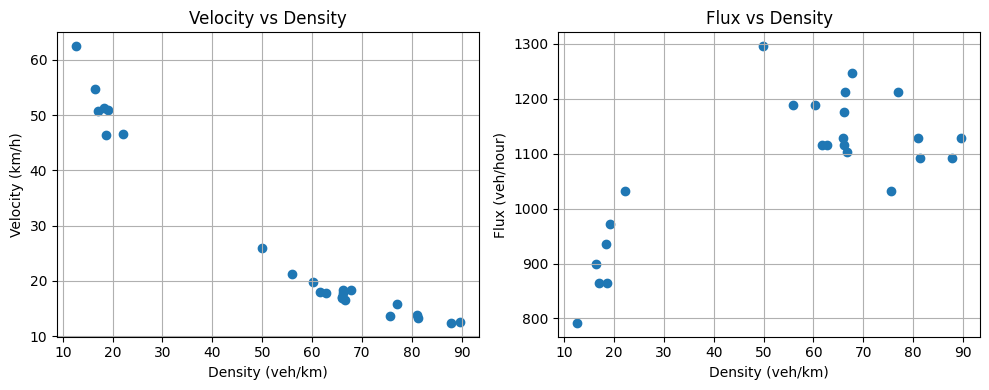

In [8]:
import numpy as np
import matplotlib.pyplot as plt

u_mph_1 = np.array([32,28,25,23,20,19,17,16,15,14,13,12,11,10,9,8,7,6])
rho_mile_1 = np.array([34,44,53,60,74,82,88,94,94,96,103,112,108,129,132,139,160,165])
f_1 = np.array([1088,1232,1325,1380,1480,1558,1496,1504,1410,1344,1339,1344,1188,1290,1188,1112,1120,990])

u_mph_2 = np.array([38.8,31.5,10.6,16.1,7.7,8.3,8.5,11.1,8.6,11.1,9.8,7.8,31.8,31.6,34.0,28.9,28.8,10.5,12.3,13.2,11.4,11.2,10.3,11.4])
rho_mile_2 = np.array([20.4,27.4,106.2,80.4,141.3,130.9,121.7,106.5,130.5,101.1,123.9,144.2,29.5,30.8,26.5,35.7,30.0,106.4,97.0,90.1,106.7,99.3,107.3,109.1])
f_2 = np.array([792,864,1128,1296,1092,1092,1032,1176,1128,1116,1212,1128,936,972,900,1032,864,1116,1188,1188,1212,1116,1104,1248])

# u_mph = u_mph_1
# rho_mile = rho_mile_1
# f = f_1

u_mph = u_mph_2
rho_mile = rho_mile_2
f = f_2

print(len(u_mph), len(rho_mile), len(f))

mile_to_km = 1.61

u_kmh = u_mph * mile_to_km
rho_km = rho_mile / mile_to_km

print("u (km/h):", u_kmh)
print("rho (veh/km):", rho_km)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(rho_km, u_kmh)
plt.xlabel("Density (veh/km)")
plt.ylabel("Velocity (km/h)")
plt.title("Velocity vs Density")
plt.grid()

plt.subplot(1,2,2)
plt.scatter(rho_km, f)
plt.xlabel("Density (veh/km)")
plt.ylabel("Flux (veh/hour)")
plt.title("Flux vs Density")
plt.grid()

plt.tight_layout()
plt.show()

a = -0.41381693335673925
b = 46.53453309685929


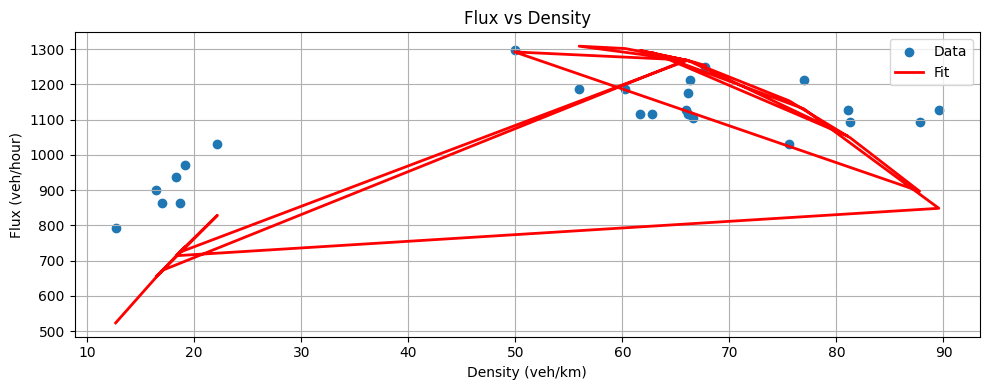

In [9]:
S2 = np.sum(rho_km**2)
S3 = np.sum(rho_km**3)
S4 = np.sum(rho_km**4)

Sf1 = np.sum(f * rho_km)
Sf2 = np.sum(f * rho_km**2)

A = np.array([[S4, S3],
              [S3, S2]])

b_vec = np.array([Sf2, Sf1])

a, b = np.linalg.solve(A, b_vec)

print("a =", a)
print("b =", b)

f_fit = a * rho_km**2 + b * rho_km

# plotting data vs fit
plt.figure(figsize=(10,4))


plt.scatter(rho_km, f, label='Data')
plt.plot(rho_km, f_fit, color='red', label='Fit', linewidth=2)
plt.xlabel("Density (veh/km)")
plt.ylabel("Flux (veh/hour)")
plt.title("Flux vs Density")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


a = -42.950, b = 23.746, C = 389.157


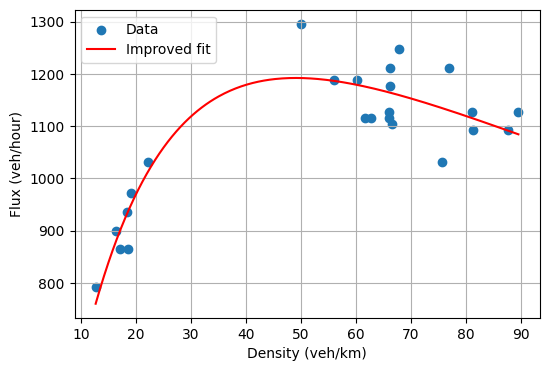

In [10]:
from scipy.optimize import curve_fit
def flux_model(rho, a, b, C):
    return C * rho / (1 + ((rho - a)/b)**2)

params, _ = curve_fit(flux_model, rho_km, f, p0=[60, 20, 1500])
a_fit, b_fit, C_fit = params

print(f"a = {a_fit:.3f}, b = {b_fit:.3f}, C = {C_fit:.3f}")

rho_fit = np.linspace(min(rho_km), max(rho_km), 300)
f_fit = flux_model(rho_fit, a_fit, b_fit, C_fit)

plt.figure(figsize=(6,4))
plt.scatter(rho_km, f, label="Data")
plt.plot(rho_fit, f_fit, 'r-', label="Improved fit")
plt.xlabel("Density (veh/km)")
plt.ylabel("Flux (veh/hour)")
plt.legend()
plt.grid()
plt.show()